<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%201/Week_1_Lecture_4_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=PyoJdMrUMqI) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%201/DL4CV_Week01_Part04.pdf)

In [ ]:
# Week 1, Lecture 4: Image Representation
from IPython.display import HTML, display

VIDEO_ID = "PyoJdMrUMqI"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

Watch on YouTube

# Week 1, Lecture 4: Image Representation

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§1.4 Image Representation**.

**What you will learn**

- Why colour is a 3-vector: how three cone types lead to RGB, and what that means for the image array.
- Read an image both as a **matrix** of intensities and as a **function** $I(x,y)$, and move between the two views.
- Classify every image operation as **point**, **local** or **global**, and reason about the cost of each.
- Apply point operations (contrast reversal, linear stretching, histogram equalization) and see where they run out.
- See why averaging removes noise, motivating local operations (the moving average) and the global Fourier view.

**Contents**
1. Colour and the eye: why RGB?
2. Image as a matrix
3. Image as a function
4. Image transformations
5. Point / local / global operations (and their cost)
6. Point operations: contrast reversal, linear stretching, histogram equalization
7. Why point operations are limited → denoising by averaging
8. Local operations: the moving average
9. Global operations: the Fourier transform

**How to run**  Runs on Colab or a local Jupyter, CPU only. Every image is bundled with `scikit-image`, so nothing is downloaded. Run the setup cell first, then go top to bottom.

## Review

The previous lecture followed **image formation**: how light, a lens and a sensor turn a 3D scene into a 2D array of measurements. This lecture starts from that array and asks how to **represent** and manipulate it, as a matrix and as a function, and how the cost of an operation depends on whether it is point, local or global.

## Setup

We rely only on images bundled with `scikit-image`, so the notebook runs without any network access.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from skimage import data, color, util, exposure
from scipy import ndimage

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap']     = 'gray'

## 1. Colour and the eye: why RGB?

The visible spectrum is continuous (VIBGYOR), yet we encode colour with just **three** numbers.
The reason is biological: the retina has three cone types, **L**ong, **M**edium and **S**hort wavelength
(plus rods for low-light intensity). Any spectrum is collapsed by the eye into three cone responses, so three
primaries (R, G, B) are enough to *reproduce* the same perceived colour.

> Fun facts: the M/L cone genes sit on the X-chromosome, so colour-blindness is far more common in men;
> animals range from 1 cone type (some nocturnal mammals) to 12 (mantis shrimp).

The curves below are a **schematic** of cone sensitivities (approximate peaks 420 / 534 / 564 nm).

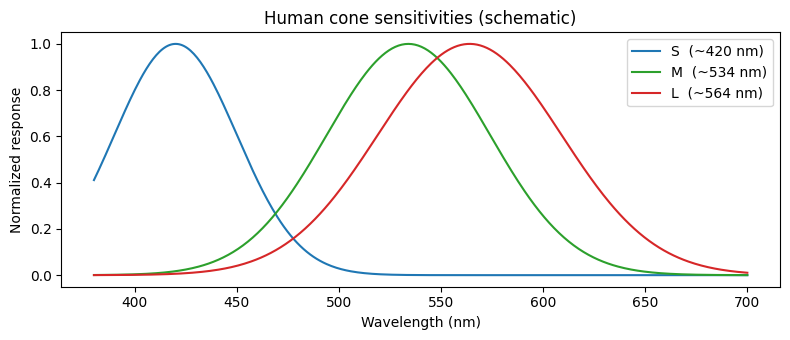

In [2]:
wl = np.linspace(380, 700, 400)
def sens(mu, s):
    y = np.exp(-0.5 * ((wl - mu) / s) ** 2)
    return y / y.max()

plt.figure(figsize=(8, 3.5))
plt.plot(wl, sens(420, 30), color='tab:blue',  label='S  (~420 nm)')
plt.plot(wl, sens(534, 40), color='tab:green', label='M  (~534 nm)')
plt.plot(wl, sens(564, 45), color='tab:red',   label='L  (~564 nm)')
plt.xlabel('Wavelength (nm)'); plt.ylabel('Normalized response')
plt.title('Human cone sensitivities (schematic)')
plt.legend(); plt.tight_layout(); plt.show()

## 2. Image as a matrix

A digital image is a 2D grid of intensity samples. With 8 bits per sample the range is
$[0, 255]$ where $0$ = black and $255$ = white. A colour image is simply **one such matrix per channel**,
giving an `(H, W, 3)` array.

In [3]:
rgb  = data.astronaut()        # RGB, uint8, shape (H, W, 3)
gray = color.rgb2gray(rgb)     # grayscale, float in [0, 1], shape (H, W)

print('rgb :', type(rgb).__name__, rgb.dtype,  rgb.shape)
print('gray:', type(gray).__name__, gray.dtype, gray.shape)

rgb : ndarray uint8 (512, 512, 3)
gray: ndarray float64 (512, 512)


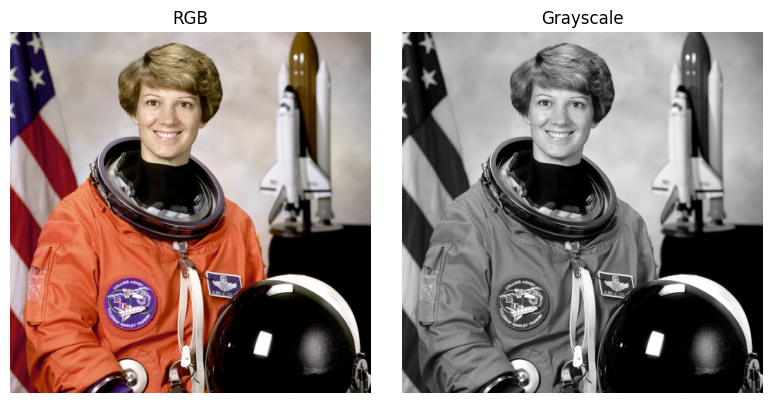

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(rgb);             ax[0].set_title('RGB')
ax[1].imshow(gray);            ax[1].set_title('Grayscale')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

Each colour channel is its own intensity matrix. Plot each with a colormap that *matches* the channel
(R with the reds map, G with greens, B with blues). Bright values mean a strong contribution of that primary.

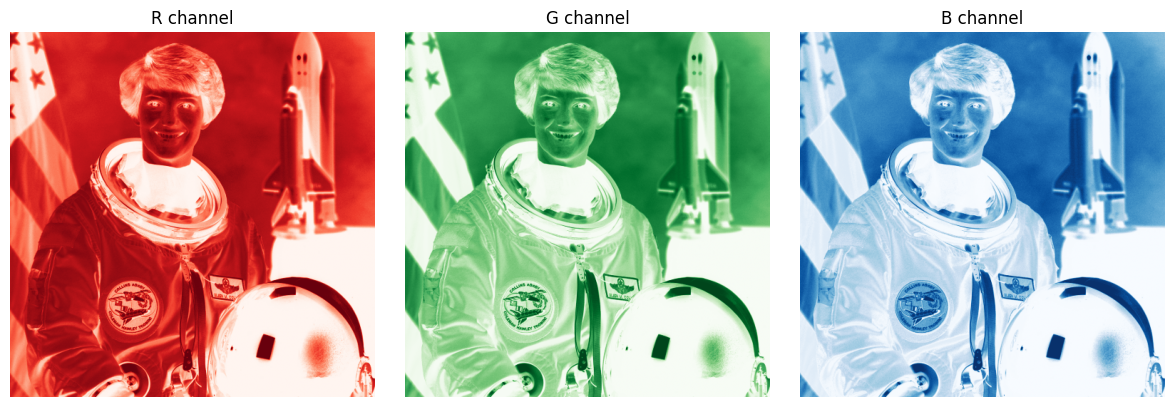

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
ax[0].imshow(rgb[:, :, 0], cmap='Reds');   ax[0].set_title('R channel')
ax[1].imshow(rgb[:, :, 1], cmap='Greens'); ax[1].set_title('G channel')
ax[2].imshow(rgb[:, :, 2], cmap='Blues');  ax[2].set_title('B channel')
for a in ax: a.axis('off')
plt.tight_layout(); plt.show()

Zooming into an 8x8 patch makes the "matrix of numbers" literal (shown as 0 to 255 intensities):

In [6]:
patch = (gray[180:188, 180:188] * 255).astype(int)
print(patch)

[[ 0  0  7 14 16 11  6 24]
 [ 0  4 12 19 17 14  5 19]
 [ 1  7 12 16 14 11  2 11]
 [ 5  9 14 13 14 14  5  7]
 [ 8  9 10 12 14 12  8  2]
 [ 8  8 12 15 12 13  5  0]
 [ 8  9 10 13 14 13  5  0]
 [13 14 13 16 13  9  9  2]]


## 3. Image as a function

A grayscale image can be modelled as a *continuous* function $f : \mathbb{R}^2 \to \mathbb{R}$, where
$f(x, y)$ is the light intensity at position $(x, y)$. A **digital** image is its discrete counterpart:
$f$ is **sampled** on a regular integer grid and **quantized** to a finite bit depth. So the values we
actually store are discrete on both axes, position and intensity.

The surface below renders one cropped region (marked in red on the full image). It *looks* like a smooth
sheet only because the plotter shades and interpolates between the samples; the stored data is the grid of
pixel values, not a continuous surface.

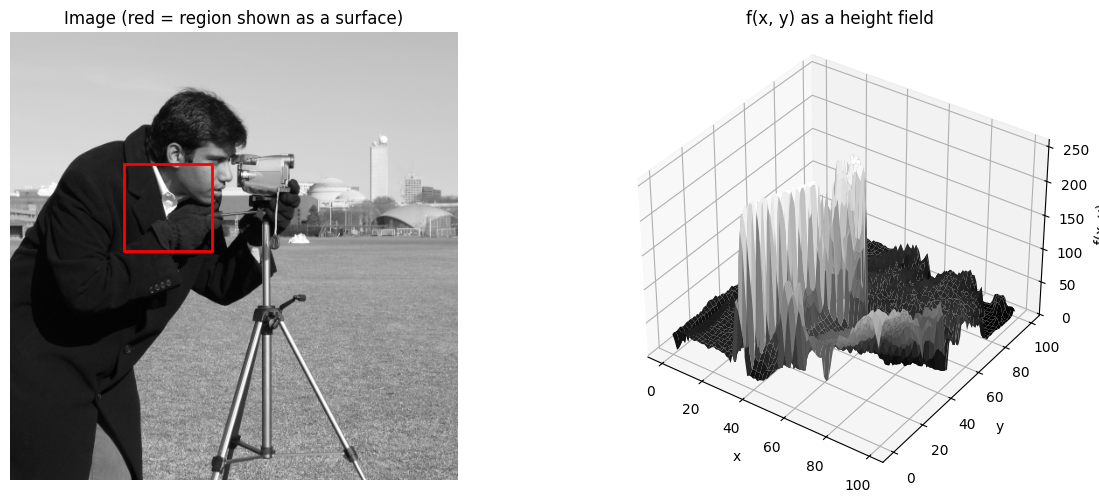

In [7]:
img_cam = data.camera()                       # 512x512 grayscale test image
r0, c0, h, w = 150, 130, 100, 100             # region to render as a surface
patch = img_cam[r0:r0 + h, c0:c0 + w]
X, Y = np.meshgrid(np.arange(w), np.arange(h))

fig = plt.figure(figsize=(13, 5))
ax1 = fig.add_subplot(121)
ax1.imshow(img_cam)
ax1.add_patch(Rectangle((c0, r0), w, h, fill=False, edgecolor='red', lw=2))
ax1.set_title('Image (red = region shown as a surface)'); ax1.axis('off')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, Y, patch.astype(float), cmap='gray', linewidth=0)
ax2.set_xlabel('x'); ax2.set_ylabel('y'); ax2.set_zlabel('f(x, y)')
ax2.set_title('f(x, y) as a height field'); ax2.view_init(elev=35, azim=-55)
plt.tight_layout(); plt.show()

The discreteness is clearest in 1-D. Take a single horizontal row and plot intensity against column: the
profile shows edges as sharp jumps, and zooming in reveals that the curve is really a sequence of discrete
samples, one per pixel.

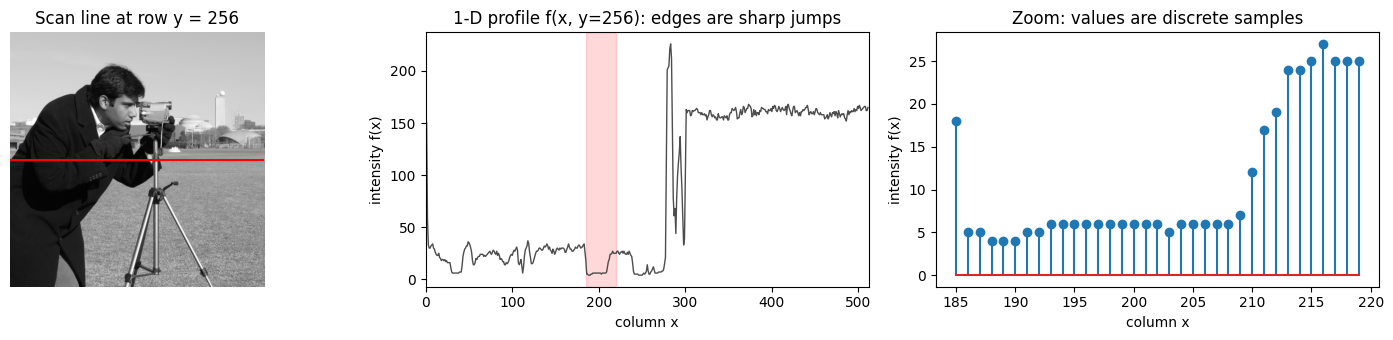

In [8]:
row = 256
seg = slice(185, 220)                          # short span to expose individual samples

fig, ax = plt.subplots(1, 3, figsize=(15, 3.5))
ax[0].imshow(img_cam); ax[0].axhline(row, color='red', lw=1.5)
ax[0].set_title(f'Scan line at row y = {row}'); ax[0].axis('off')

ax[1].plot(img_cam[row], color='0.3', lw=1)
ax[1].axvspan(seg.start, seg.stop, color='red', alpha=0.15)
ax[1].set_xlim(0, img_cam.shape[1])
ax[1].set_xlabel('column x'); ax[1].set_ylabel('intensity f(x)')
ax[1].set_title(f'1-D profile f(x, y={row}): edges are sharp jumps')

ax[2].stem(np.arange(seg.start, seg.stop), img_cam[row, seg])
ax[2].set_xlabel('column x'); ax[2].set_ylabel('intensity f(x)')
ax[2].set_title('Zoom: values are discrete samples')
plt.tight_layout(); plt.show()

## 4. Image transformations

Simple transforms act on intensities or coordinates, e.g. a brightness shift
$\hat I(x, y) = I(x, y) + 20$ or a horizontal flip $\hat I(x, y) = I(-x, y)$.

**Watch the dtype.** Images are `uint8`, so `img + 100` overflows: a value like $200 + 100 = 300$ wraps to
$300 \bmod 256 = 44$, producing dark speckles in bright areas. The fix is to compute in a wider type and
**saturate** with `np.clip`.

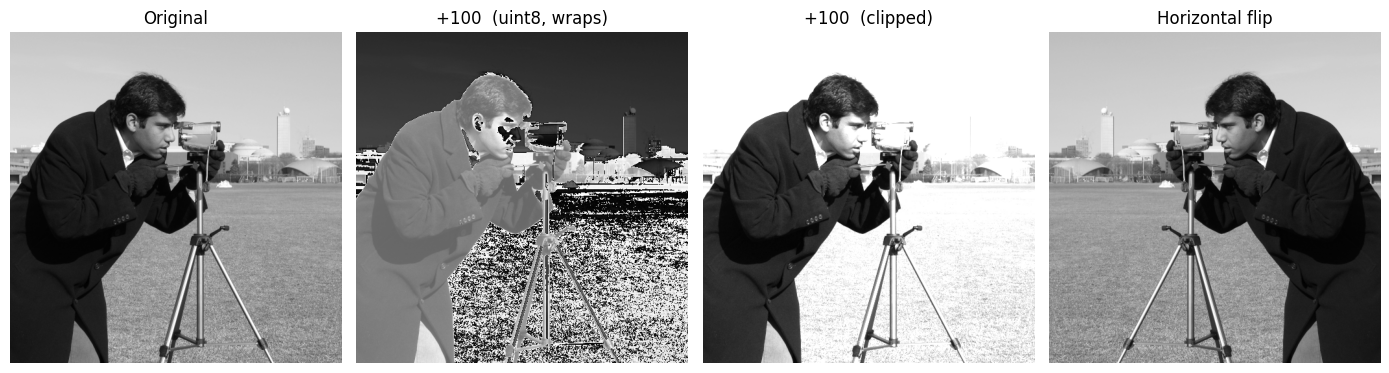

In [9]:
img     = data.camera()
naive   = img + 100                                              # uint8 wraps mod 256
clipped = np.clip(img.astype(np.int16) + 100, 0, 255).astype(np.uint8)
flip    = img[:, ::-1]                                           # I(x, y) -> I(-x, y)

fig, ax = plt.subplots(1, 4, figsize=(14, 4))
for a, im, t in zip(ax, [img, naive, clipped, flip],
                    ['Original', '+100  (uint8, wraps)', '+100  (clipped)', 'Horizontal flip']):
    a.imshow(im); a.set_title(t); a.axis('off')
plt.tight_layout(); plt.show()

## 5. Point, local and global operations

Image operations are grouped by *which inputs* determine an output pixel at $(m_0, n_0)$:

| Type | Output at $(m_0, n_0)$ depends on | Cost per pixel |
|------|-----------------------------------|----------------|
| **Point**  | the input at the *same* coordinate | $O(1)$ |
| **Local**  | a $p \times p$ neighbourhood       | $O(p^2)$ |
| **Global** | *all* $N \times N$ pixels          | $O(N^2)$ |

The next sections give a representative operation from each class.

## 6. Point operations

### 6.1 Contrast reversal (negative)

$$\hat I(m_0, n_0) = I_{MAX} - I(m_0, n_0) + I_{MIN}$$

For an 8-bit image ($I_{MAX}=255,\ I_{MIN}=0$) this is just `255 - img`, which stays in range and is overflow-safe.

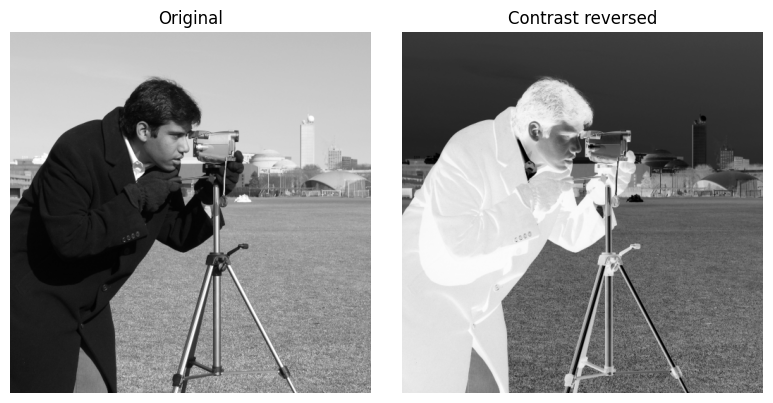

In [10]:
img = data.camera()
neg = 255 - img

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(img); ax[0].set_title('Original');          ax[0].axis('off')
ax[1].imshow(neg); ax[1].set_title('Contrast reversed'); ax[1].axis('off')
plt.tight_layout(); plt.show()

### 6.2 Linear contrast stretching

Map the used range $[\min I, \max I]$ onto the full range $[I_{MIN}, I_{MAX}]$:

$$\hat I(m_0, n_0) = \big(I(m_0, n_0) - \min_{x,y} I\big)\cdot
\frac{I_{MAX} - I_{MIN}}{\max_{x,y} I - \min_{x,y} I} + I_{MIN}$$

We synthesize a low-contrast image (intensities squeezed into a narrow band) and stretch it back.
Note `vmin/vmax` are fixed in `imshow` so the washed-out input is shown faithfully instead of being auto-rescaled.

low-contrast range: (90, 166)
stretched range   : (0, 255)


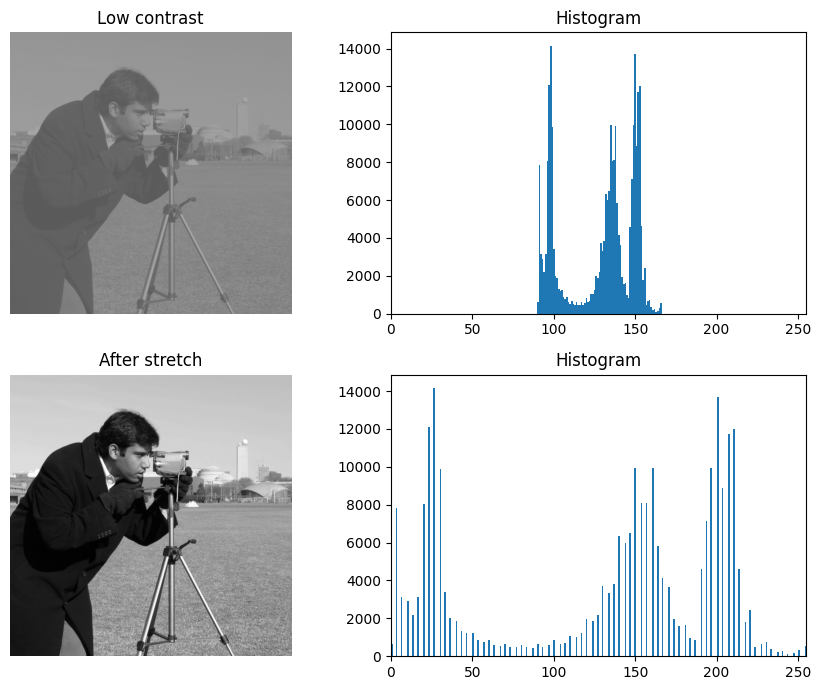

In [11]:
img = data.camera()
low = (img * 0.3 + 90).astype(np.uint8)          # squeeze range into ~[90, 166]
lo, hi = int(low.min()), int(low.max())
stretch = ((low.astype(float) - lo) * (255.0 / (hi - lo))).astype(np.uint8)

print('low-contrast range:', (lo, hi))
print('stretched range   :', (int(stretch.min()), int(stretch.max())))

fig, ax = plt.subplots(2, 2, figsize=(9, 7))
ax[0, 0].imshow(low, vmin=0, vmax=255);     ax[0, 0].set_title('Low contrast'); ax[0, 0].axis('off')
ax[0, 1].hist(low.ravel(), bins=256, range=(0, 255));     ax[0, 1].set_title('Histogram'); ax[0, 1].set_xlim(0, 255)
ax[1, 0].imshow(stretch, vmin=0, vmax=255); ax[1, 0].set_title('After stretch'); ax[1, 0].axis('off')
ax[1, 1].hist(stretch.ravel(), bins=256, range=(0, 255)); ax[1, 1].set_title('Histogram'); ax[1, 1].set_xlim(0, 255)
plt.tight_layout(); plt.show()

### 6.3 Histogram equalization (homework)

Linear stretching only rescales; it cannot redistribute clustered intensities. **Histogram equalization**
remaps intensities so the output histogram is approximately uniform. The transform is the (scaled)
**cumulative distribution function**:

$$s_k = T(r_k) = (L-1)\sum_{j=0}^{k} p_r(r_j) = \frac{L-1}{MN}\sum_{j=0}^{k} n_j$$

where $n_j$ is the count of pixels with intensity $r_j$, $MN$ the total pixel count, and $L=256$.
Implementing the formula directly (this is exactly the derivation the lecture asks for):

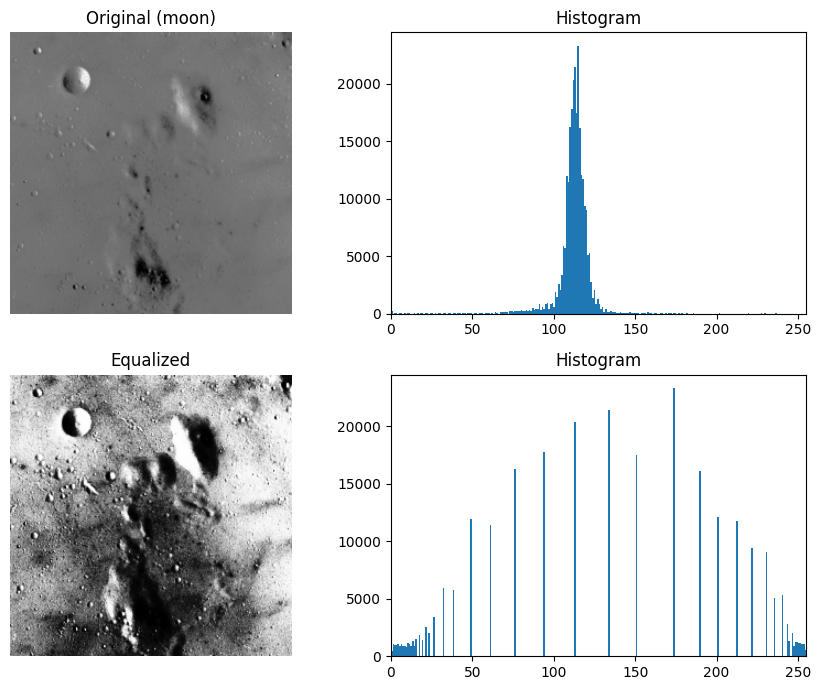

In [12]:
img = data.moon()                                # a genuinely low-contrast image
L = 256
hist = np.bincount(img.ravel(), minlength=L)
cdf  = np.cumsum(hist)
T    = np.round((L - 1) * cdf / cdf[-1]).astype(np.uint8)   # s_k = (L-1) * CDF
eq   = T[img]                                               # apply the mapping

fig, ax = plt.subplots(2, 2, figsize=(9, 7))
ax[0, 0].imshow(img); ax[0, 0].set_title('Original (moon)'); ax[0, 0].axis('off')
ax[0, 1].hist(img.ravel(), bins=256, range=(0, 255)); ax[0, 1].set_title('Histogram'); ax[0, 1].set_xlim(0, 255)
ax[1, 0].imshow(eq);  ax[1, 0].set_title('Equalized');      ax[1, 0].axis('off')
ax[1, 1].hist(eq.ravel(),  bins=256, range=(0, 255)); ax[1, 1].set_title('Histogram'); ax[1, 1].set_xlim(0, 255)
plt.tight_layout(); plt.show()

In [13]:
# Cross-check against the library (skimage interpolates, so expect a small difference)
ref = (exposure.equalize_hist(img) * 255).astype(np.uint8)
print('max |manual - skimage|:', int(np.abs(eq.astype(int) - ref.astype(int)).max()))

max |manual - skimage|: 1


## 7. Why point operations are limited

A single pixel's value blends many factors (light source, surface geometry and material, sensor noise, colour
encoding), so it rarely tells the whole story. For a *still scene*, one purely point-wise way to fight
**zero-mean sensor noise** is to capture $N$ frames and average them. The noise std then shrinks as
$\sigma \to \sigma/\sqrt{N}$.

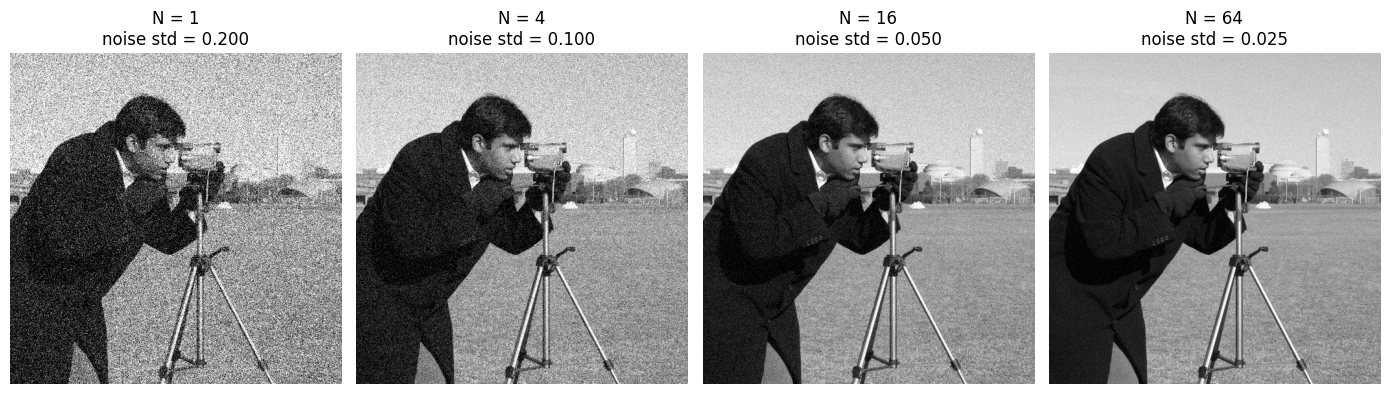

theory  sigma/sqrt(N)  at N=64 : 0.025


In [14]:
clean = util.img_as_float(data.camera())
sigma = 0.2
noisy = lambda: clean + np.random.normal(0, sigma, clean.shape)

Ns = [1, 4, 16, 64]
fig, ax = plt.subplots(1, len(Ns), figsize=(14, 4))
for a, N in zip(ax, Ns):
    avg  = np.mean([noisy() for _ in range(N)], axis=0)
    meas = float((avg - clean).std())
    a.imshow(np.clip(avg, 0, 1)); a.set_title(f'N = {N}\nnoise std = {meas:.3f}'); a.axis('off')
plt.tight_layout(); plt.show()

print(f'theory  sigma/sqrt(N)  at N=64 : {sigma / np.sqrt(64):.3f}')

If you only have a *single* image, averaging across frames is impossible, so you instead average over a
spatial neighbourhood, which is a **local** operation.

## 8. Local operations: the moving average

Replace each pixel by the mean of its $p \times p$ neighbourhood, a simple blur or smoother. First, the
worked grid from the lecture: a $3\times3$ box average turns the sharp `0/90` block into a smoothly ramped
output (`0, 10, 20, 30, ...`).

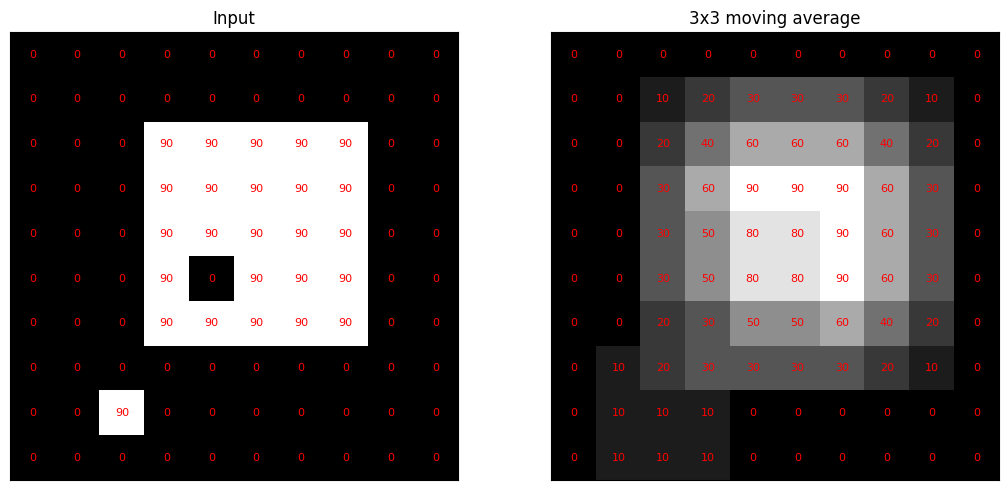

In [15]:
grid = np.zeros((10, 10))
grid[2:7, 3:8] = 90          # bright block
grid[5, 4]     = 0           # one dark pixel inside it
grid[8, 2]     = 90          # one stray bright pixel
out = ndimage.uniform_filter(grid, size=3, mode='constant')   # 3x3 box mean

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
for a, M, t in zip(ax, [grid, out], ['Input', '3x3 moving average']):
    a.imshow(M, cmap='gray', vmin=0, vmax=90); a.set_title(t)
    for (i, j), v in np.ndenumerate(M):
        a.text(j, i, f'{v:.0f}', ha='center', va='center', color='red', fontsize=8)
    a.set_xticks([]); a.set_yticks([])
plt.tight_layout(); plt.show()

A naive implementation slides the window explicitly, costing $O(p^2)$ work per pixel. We verify it matches the
optimized `uniform_filter`, then use the fast routine on a real image at several window sizes.

In [16]:
def box_average_naive(img, k):
    p   = k // 2
    pad = np.pad(img, p, mode='constant')        # zero padding keeps output size = input size
    out = np.zeros_like(img, dtype=float)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            out[i, j] = pad[i:i + k, j:j + k].mean()
    return out

crop = data.camera()[:128, :128].astype(float)
slow = box_average_naive(crop, 9)
fast = ndimage.uniform_filter(crop, size=9, mode='constant')
print('naive vs uniform_filter, max diff:', float(np.abs(slow - fast).max()))

naive vs uniform_filter, max diff: 2.8421709430404007e-13


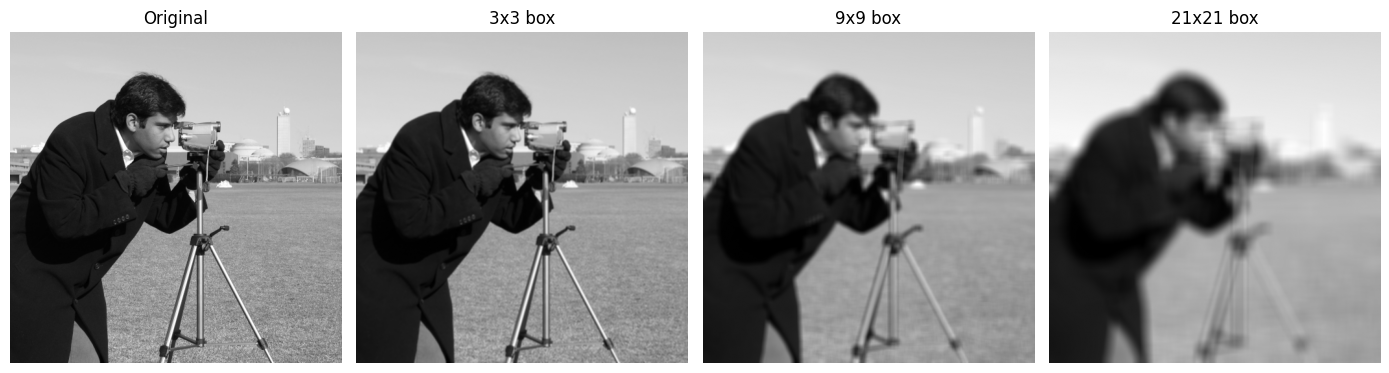

In [17]:
img   = data.camera().astype(float)
sizes = [3, 9, 21]
fig, ax = plt.subplots(1, len(sizes) + 1, figsize=(14, 4))
ax[0].imshow(img); ax[0].set_title('Original'); ax[0].axis('off')
for a, k in zip(ax[1:], sizes):
    a.imshow(ndimage.uniform_filter(img, size=k, mode='reflect'))
    a.set_title(f'{k}x{k} box'); a.axis('off')
plt.tight_layout(); plt.show()

*Note:* the box filter is **separable** (a 2D box = two 1D box passes), and integral images give an
$O(1)$-per-pixel version independent of $p$. Both are far cheaper than the naive $O(p^2)$ loop.

## 9. Global operations: the Fourier transform

Here every output value depends on **all** input pixels. The 2D discrete Fourier transform

$$F(u, v) = \sum_{x=0}^{M-1}\sum_{y=0}^{N-1} f(x, y)\, e^{-j 2\pi (ux/M + vy/N)}$$

moves the image to the frequency domain. After centering with `fftshift`, low frequencies sit at the middle
and sharp edges spread energy outward. We revisit frequency-domain filtering later in the course.

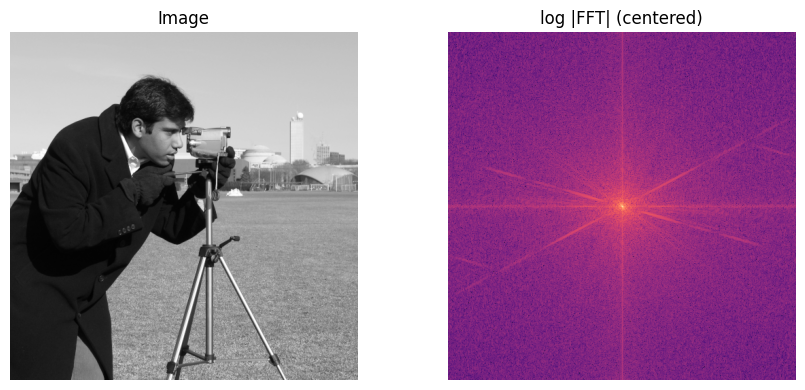

In [18]:
img = data.camera().astype(float)
F   = np.fft.fftshift(np.fft.fft2(img))
mag = np.log1p(np.abs(F))                          # log scale for visibility

fig, ax = plt.subplots(1, 2, figsize=(9, 4))
ax[0].imshow(img);            ax[0].set_title('Image');               ax[0].axis('off')
ax[1].imshow(mag, cmap='magma'); ax[1].set_title('log |FFT| (centered)'); ax[1].axis('off')
plt.tight_layout(); plt.show()

---

## Key takeaways

| Concept | Key takeaway |
|---|---|
| **RGB colour** | Matches the three cone types (L, M, S) in human vision, so three primaries suffice to reproduce perceived colour |
| **Image as a matrix** | `uint8` array of shape `(H, W)` or `(H, W, 3)`; values run 0 (black) to 255 (white), one matrix per channel |
| **Image as a function** | $f : \mathbb{R}^2 \to \mathbb{R}$ gives intensity at $(x, y)$; a digital image is this function sampled on a grid and quantized, so the stored values are discrete on both axes |
| **Transformations** | Point-wise intensity or coordinate maps, e.g. $\hat I = I + b$ (brightness) and $\hat I(x, y) = I(-x, y)$ (flip); compute in a wider type and clip to avoid `uint8` overflow |
| **Point operations** | Output depends only on the same pixel; $O(1)$ per pixel. Examples: contrast reversal $I_{MAX} - I + I_{MIN}$, linear stretching, histogram equalization (transform = scaled CDF) |
| **Local operations** | Output depends on a $p \times p$ neighbourhood; $O(p^2)$ per pixel naively. Example: moving average / box filter (low-pass smoothing) |
| **Global operations** | Output depends on all $N \times N$ pixels; $O(N^2)$ per value. Example: the 2D Fourier transform (centre = low frequencies, edges = high) |

**Why point operations are limited:** a single pixel mixes lighting, geometry, sensor noise and colour, so averaging $N$ frames of a still scene cuts zero-mean noise as $\sigma / \sqrt{N}$; with only one image you instead average spatially, which is a local operation.

**Further reading:** Szeliski, *Computer Vision: Algorithms and Applications*, Chapter 3.1  
**Homework:** Derive the histogram equalization formula from first principles (PDF/CDF transformation).